In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import mediapipe as mp
from keras import layers
import seaborn as sns
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, log_loss

import keras
import keras_tuner as kt

from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, AdamW
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model
from mediapipe.tasks.python.vision import face_landmarker


In [2]:
import torch
torch.cuda.is_available()

True

### FACE LANDMARKER

In [3]:
'''
base_oprtions - is to specify model path
options - is to specify:
 - output_face_blendshapes (True to get blendshapes)
 - output_facial_transformation_matrixes(True to get transformation matrixes)
 - num_faces(1 to detect one face)
detector - is to create face landmarker object to detect face landmarks
'''
base_options = python.BaseOptions(model_asset_path='../face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)


TRAIN_DATA_PATH = "../affectnet_dataset/Train"
TEST_DATA_PATH = "../affectnet_dataset/Test"
ORIGINAL_DATA_PATH = "../affectnet_dataset"
# CLAHE_DATASET_PATH = "../clahe_dataset"
# MASK_DATASET_PATH = "../mask_dataset"

EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)
SAVED_MODEL = "../saved_models/mlp_kt_model.h5"

In [4]:
keypoints_dir = "../affectnet_keypoints"

os.makedirs(keypoints_dir, exist_ok=True)

data_dirs = {
    "train": TRAIN_DATA_PATH,
    "test": TEST_DATA_PATH
}

In [5]:
folder = "../affectnet_keypoints/train/contempt"

# List all .npy files to check if keypoints are saved correctly
files = [f for f in os.listdir(folder) if f.endswith(".npy")]

first_img = os.path.join(folder, files[0])
keypoints = np.load(first_img)
print(keypoints.shape)

(478, 3)


In [6]:
# Load keypoints array and labels from the dataset
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

X, y = load_keypoints_dataset("../affectnet_keypoints/train")

In [7]:
y[:5]

array(['anger', 'anger', 'anger', 'anger', 'anger'], dtype='<U8')

In [8]:
'''
LabelEncoder() - to convert string lbl to int
to_categorical() - to convert int lbl to one-hot encoding
reshape - to convert 3D array (samples, landmarks, coordinates) 
to 2D array (samples, features), because MLP expects 2D input (samples, features)

StandardScaler() - to standardize features by removing the mean and scaling to unit variance
(data is scaled to have a standard deviation of 1)
'''
le = LabelEncoder()
y = le.fit_transform(y)
# y = to_categorical(y)

# Split FIRST
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)

# THEN standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
print(X_train.shape, y_train.shape)

# (12830, 1434) (12830, 8)
# number of samples - 12830
# number of features per sample - 1434 (478 features * 3 x,y,z coordinates)

(12862, 1434) (12862,)


In [9]:
'''
mp_landmarker_model_keras .ipynb"
one-hot encoded labels are in the format of binary vectors,
where each vector has a length equal to the number of classes,
and only the index corresponding to the class label is set to 1, while all other indices are set to 0.
'''
y[3400:3410]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
# Weight parameter in CrossEntropyLoss function to apply a weight to each class based on its frequency
# class weights will be given by
# n_samples / (n_classes * np.bincount(y))
# np.bincount counts the occurrences of value in an input array
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights = dict(zip(np.unique(y_train), class_weights_array))
print("Class weights array:", weights)

Class weights array: {np.int64(0): np.float64(1.3375623960066556), np.int64(1): np.float64(1.2810756972111554), np.int64(2): np.float64(1.6591847265221877), np.int64(3): np.float64(1.3265264026402641), np.int64(4): np.float64(0.861140867702196), np.int64(5): np.float64(0.7375), np.int64(6): np.float64(0.649071457408155), np.int64(7): np.float64(0.945735294117647)}


In [11]:
def build_model(hp):
    model = tf.keras.Sequential([
        layers.Input(shape=(1434,)),

        # Block 1
        layers.Dense(
            512,
            kernel_regularizer=tf.keras.regularizers.l2(
                hp.Float('l2_1', 1e-5, 1e-3, sampling='log')
            )
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(hp.Float('dropout1',min_value=0.1, max_value=0.4, step=0.1)),
        
        # Block 2
        layers.Dense(
            256,
            kernel_regularizer=tf.keras.regularizers.l2(
                hp.Float('l2_2', 1e-5, 1e-3, sampling='log')
            )
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(hp.Float('dropout2',min_value=0.1, max_value=0.4, step=0.1)),

        # Block 3
        layers.Dense(
            128,
            kernel_regularizer=tf.keras.regularizers.l2(
                hp.Float('l2_3', 1e-5, 1e-3, sampling='log')
            )
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(hp.Float('dropout3',min_value=0.1, max_value=0.4, step=0.1)),

        layers.Dense(8, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=AdamW(hp.Float('lr',min_value=1e-5, max_value=1e-3, sampling='log')),
        metrics=['accuracy']
    )
    return model

In [12]:
'''
Initialize a tuner (here, HyperBand). 
We use objective to specify the objective to select the best models,
and we use max_trials to specify the number of different models to try.
'''
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3, # Reduction factor 3x fewer models in the next round
    directory='keras_tuner_results',
    project_name='emotion_recognition'
)

Reloading Tuner from keras_tuner_results\emotion_recognition\tuner0.json


In [13]:
tuner.search_space_summary()

Search space summary
Default search space size: 5
l2_1 (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.0001, 'step': None, 'sampling': 'log'}
dropout1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
l2_2 (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.0001, 'step': None, 'sampling': 'log'}
dropout2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
lr (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'log'}


In [14]:
tuner.search(
    X_train, y_train,
    epochs=10,
    validation_data=(X_val, y_val)
)

In [15]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = build_model(best_hp)
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       734,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 903,560 (3.45 MB)

 Trainable params: 901,768 (3.44 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [16]:
best_hp.values

{'l2_1': 1.0118631389888083e-05,
 'dropout1': 0.1,
 'l2_2': 5.353199386462578e-05,
 'dropout2': 0.2,
 'lr': 0.0004581466994406442,
 'tuner/epochs': 20,
 'tuner/initial_epoch': 7,
 'tuner/bracket': 1,
 'tuner/round': 1,
 'tuner/trial_id': '0023',
 'l2_3': 1e-05,
 'dropout3': 0.1}

In [17]:
tuner.results_summary()

Results summary
Results in keras_tuner_results\emotion_recognition
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0024 summary
Hyperparameters:
l2_1: 1.0118631389888083e-05
dropout1: 0.1
l2_2: 5.353199386462578e-05
dropout2: 0.2
lr: 0.0004581466994406442
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0023
l2_3: 1e-05
dropout3: 0.1
Score: 0.4063955247402191

Trial 0016 summary
Hyperparameters:
l2_1: 1.2485419367126874e-05
dropout1: 0.1
l2_2: 5.1487845877804396e-05
dropout2: 0.30000000000000004
lr: 0.0009065729012187748
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0012
Score: 0.4029804468154907

Trial 0025 summary
Hyperparameters:
l2_1: 5.195158519999008e-05
dropout1: 0.4
l2_2: 5.812948219172319e-05
dropout2: 0.1
lr: 0.00028612572125398967
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0018
Score: 0.3930456340312958

Trial 0017 summar

In [18]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint(SAVED_MODEL, monitor='val_loss', save_best_only=True)
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,    
    min_lr=1e-6
)
csv_logger = CSVLogger('../logs/mlp_weighted_loss_training_log.csv')

In [19]:
import time
start = time.time()
history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=weights,
    callbacks=[es, mc, csv_logger,rlr]
)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/100
399/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3898 - loss: 1.6702

402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4293 - loss: 1.5173 - val_accuracy: 0.5286 - val_loss: 1.2093 - learning_rate: 4.5815e-04
Epoch 2/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4967 - loss: 1.3478

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4997 - loss: 1.3399 - val_accuracy: 0.5553 - val_loss: 1.1603 - learning_rate: 4.5815e-04
Epoch 3/100
391/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5192 - loss: 1.2806

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5142 - loss: 1.2799 - val_accuracy: 0.5538 - val_loss: 1.1546 - learning_rate: 4.5815e-04
Epoch 4/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5387 - loss: 1.2513

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5368 - loss: 1.2501 - val_accuracy: 0.5780 - val_loss: 1.1025 - learning_rate: 4.5815e-04
Epoch 5/100
395/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5434 - loss: 1.2392

...

402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6653 - loss: 0.9565 - val_accuracy: 0.6430 - val_loss: 0.9521 - learning_rate: 3.7110e-06
Epoch 40/100
400/402 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6684 - loss: 0.9449

402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6673 - loss: 0.9495 - val_accuracy: 0.6468 - val_loss: 0.9509 - learning_rate: 3.7110e-06
Epoch 41/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6679 - loss: 0.9482 - val_accuracy: 0.6437 - val_loss: 0.9534 - learning_rate: 3.7110e-06
Epoch 42/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6691 - loss: 0.9437 - val_accuracy: 0.6452 - val_loss: 0.9512 - learning_rate: 3.7110e-06
Epoch 43/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6672 - loss: 0.9496 - val_accuracy: 0.6449 - val_loss: 0.9520 - learning_rate: 3.7110e-06
Epoch 44/100
395/402 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6737 - loss: 0.9420

402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6679 - loss: 0.9495 - val_accuracy: 0.6465 - val_loss: 0.9507 - learning_rate: 1.1133e-06
Epoch 45/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6707 - loss: 0.9459 - val_accuracy: 0.6458 - val_loss: 0.9515 - learning_rate: 1.1133e-06
Epoch 46/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6683 - loss: 0.9480 - val_accuracy: 0.6458 - val_loss: 0.9519 - learning_rate: 1.1133e-06
Epoch 47/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6696 - loss: 0.9435 - val_accuracy: 0.6455 - val_loss: 0.9516 - learning_rate: 1.1133e-06
Epoch 48/100
400/402 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6692 - loss: 0.9461

402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6713 - loss: 0.9431 - val_accuracy: 0.6455 - val_loss: 0.9506 - learning_rate: 1.0000e-06
Epoch 49/100
396/402 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6741 - loss: 0.9337

402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6693 - loss: 0.9494 - val_accuracy: 0.6468 - val_loss: 0.9492 - learning_rate: 1.0000e-06
Epoch 50/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6689 - loss: 0.9477 - val_accuracy: 0.6458 - val_loss: 0.9518 - learning_rate: 1.0000e-06
Epoch 51/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6710 - loss: 0.9407 - val_accuracy: 0.6471 - val_loss: 0.9523 - learning_rate: 1.0000e-06
Epoch 52/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6685 - loss: 0.9451 - val_accuracy: 0.6458 - val_loss: 0.9516 - learning_rate: 1.0000e-06
Epoch 53/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6681 - loss: 0.9499 - val_accuracy: 0.6468 - val_loss: 0.9519 - learning_rate: 1.0000e-06
Epoch 54/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6700 - loss: 0.9432 - val_accuracy: 0.6477 - val_loss: 0.9500 - learning_rate: 1.0000e-06
Epoch 55/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy:

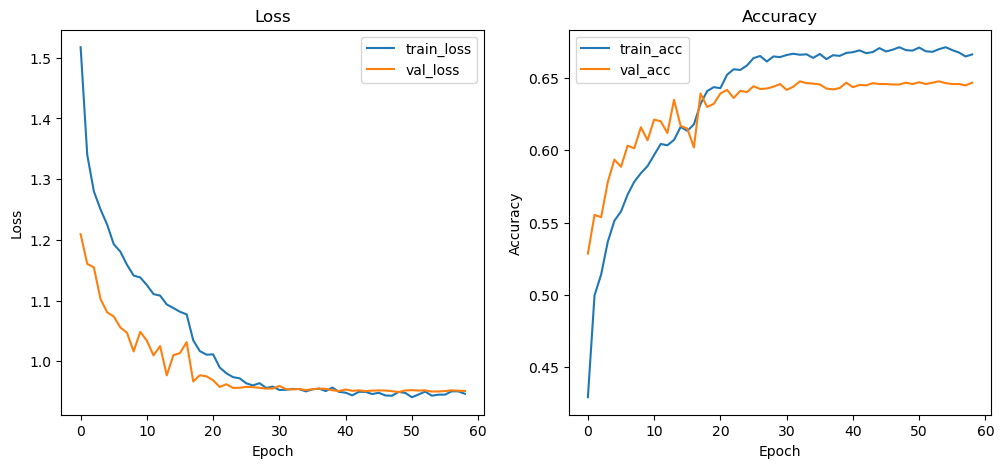

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [21]:
model = load_model(SAVED_MODEL)

In [22]:
# load test data
X_test, y_test = load_keypoints_dataset("../affectnet_keypoints/test")

X_test = X_test.reshape(X_test.shape[0], -1)
# Encode labels using  same LabelEncoder as training
# `le` is label encoder fitted on training labels
y_test_enc = le.transform(y_test) 
# y_test_cat = to_categorical(y_test_enc)  # one-hot

# scaler is the StandardScaler fitted on training data
# scalar.transform() standardizes test features using training mean and std
X_test = scaler.transform(X_test)

print("X_test shape:", X_test.shape)
print("y_test_enc shape:", y_test_enc.shape)

X_test shape: (14480, 1434)
y_test_enc shape: (14480,)


In [23]:
# Predict probabilities
yhat_probs = model.predict(X_test)  # shape (num_samples, 8)

# Convert probabilities to predicted class indices
yhat = np.argmax(yhat_probs, axis=1)

# True class indices
ytrue = y_test_enc

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [24]:
from sklearn.metrics import accuracy_score, log_loss

acc = accuracy_score(ytrue, yhat)
loss = log_loss(ytrue, yhat_probs)
print(f"Test Accuracy: {acc*100:.2f}%, Test Log Loss: {loss:.4f}")

Test Accuracy: 64.00%, Test Log Loss: 1.1868


Evaluating on Test Set...
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6400 - loss: 1.2237
Test Accuracy: 64.00%
Generating predictions...

Classification Report:

              precision    recall  f1-score   support

       anger       0.56      0.44      0.49      1705
    contempt       0.59      0.66      0.62      1312
     disgust       0.42      0.46      0.44      1243
        fear       0.54      0.47      0.50      1658
       happy       0.91      0.91      0.91      2703
     neutral       0.73      0.95      0.82      2367
         sad       0.54      0.56      0.55      1576
    surprise       0.50      0.38      0.43      1916

    accuracy                           0.64     14480
   macro avg       0.60      0.60      0.60     14480
weighted avg       0.63      0.64      0.63     14480



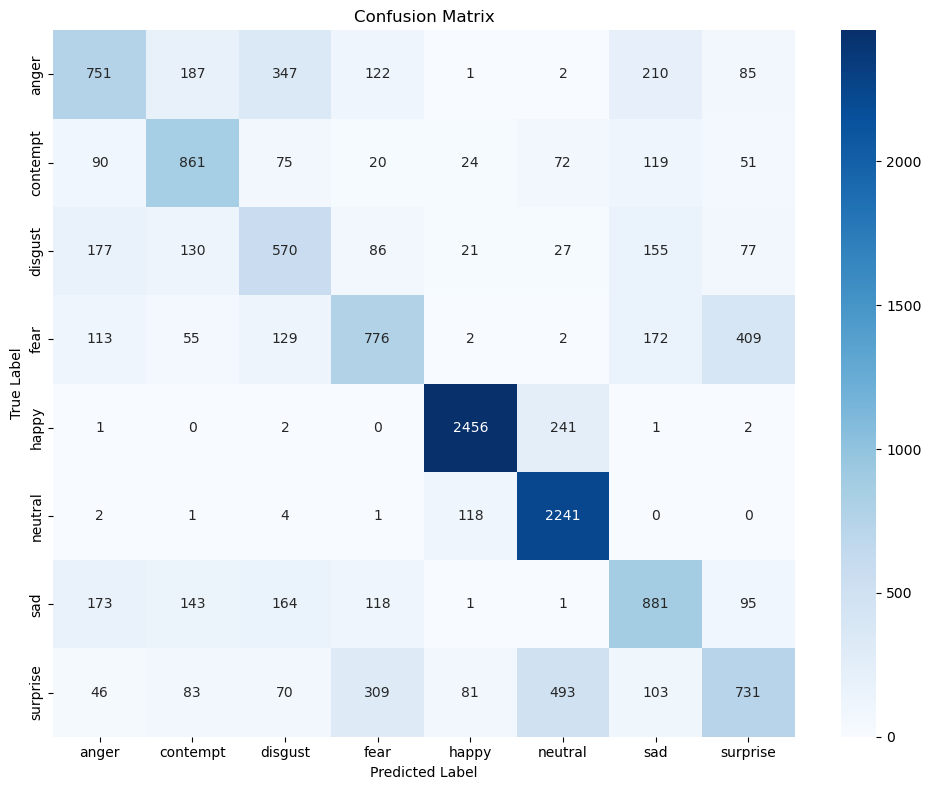

In [25]:
def report_test_results_keypoints(X_test, y_test_enc, model, le):
    print("Evaluating on Test Set...")
    
    loss, accuracy = model.evaluate(X_test, y_test_enc) 
    print(f"Test Accuracy: {accuracy*100:.2f}%")

    print("Generating predictions...")
    predictions = model.predict(X_test, verbose=0)
    y_pred_indices = np.argmax(predictions, axis=1)

    class_labels = le.classes_

    print("\nClassification Report:\n")
    print(classification_report(
        y_test_enc,
        y_pred_indices,
        target_names=class_labels
    ))

    cm = confusion_matrix(y_test_enc, y_pred_indices)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

report_test_results_keypoints(X_test, y_test_enc, model, le)

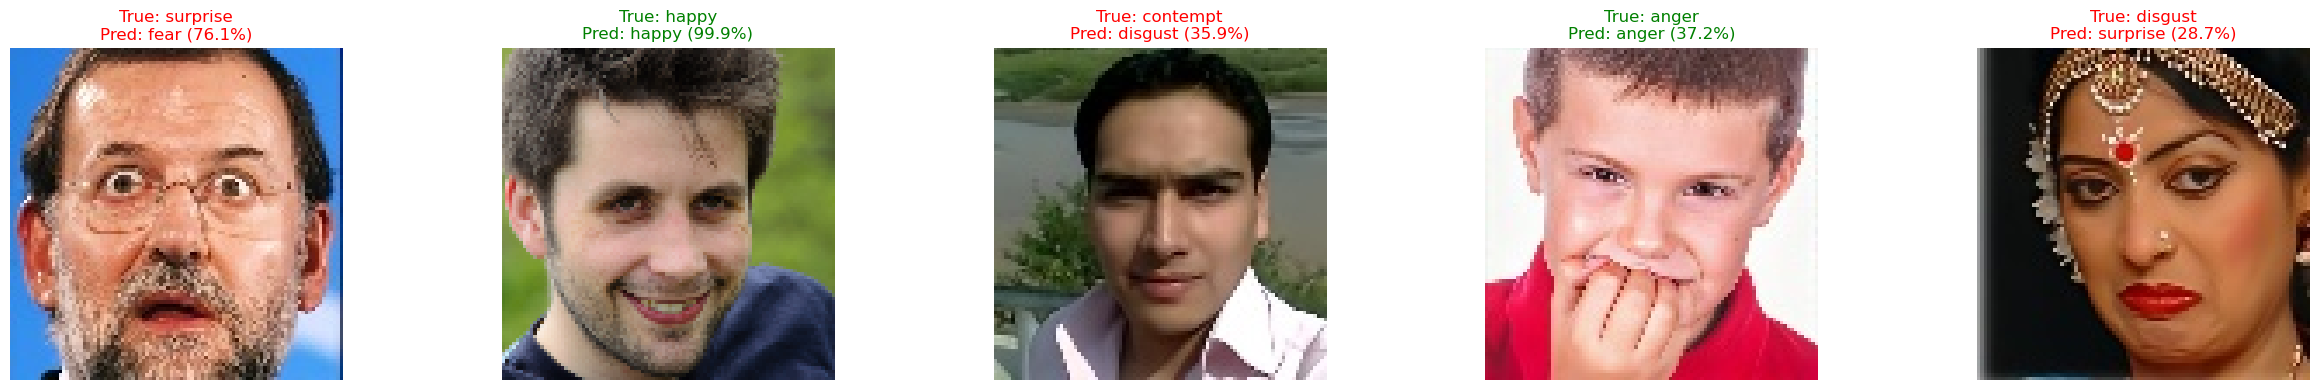

In [26]:
def predict_images_with_keypoints(image_dir, model, scaler, le, n=5):
    images_paths = []

    # collect all images
    for class_name in os.listdir(image_dir):
        class_path = os.path.join(image_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            if img_name.startswith("."):
                continue
            images_paths.append((os.path.join(class_path, img_name), class_name))

    # pick random samples
    samples = np.random.choice(len(images_paths), n, replace=False)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    for i, idx in enumerate(samples):
        img_path, true_label = images_paths[idx]

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # --- KEYPOINT EXTRACTION ---
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        results = detector.detect(mp_image)

        if not results.face_landmarks:
            pred_label = "No face"
            confidence = 0
        else:
            face_landmarks = results.face_landmarks[0]

            keypoints = np.array([[lm.x, lm.y, lm.z] for lm in face_landmarks])
            keypoints = keypoints.reshape(1, -1)

            keypoints = scaler.transform(keypoints)

            pred_prob = model.predict(keypoints, verbose=0)[0]
            pred_idx = np.argmax(pred_prob)
            pred_label = le.classes_[pred_idx]
            confidence = pred_prob[pred_idx] * 100

        axes[i].imshow(img_rgb)
        axes[i].axis("off")

        color = "green" if pred_label == true_label else "red"

        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
            color=color
        )

    plt.tight_layout()
    plt.show()

predict_images_with_keypoints(
    "../affectnet_dataset/Test",
    model,
    scaler,
    le,
    n=5
)